# Step 1: Import Libraries
In this cell, we import all the required libraries such as NumPy, OpenCV, TensorFlow, and Gradio...


In [22]:
# Colab: install deps
!pip -q install opencv-python scikit-image tensorflow==2.15.0 gradio==4.44.0 matplotlib scikit-learn


ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0)
ERROR: No matching distribution found for tensorflow==2.15.0


In [23]:
import os, glob, shutil, random, math, json
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.feature import graycomatrix, graycoprops
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix
import itertools


The below cell defines all the important configuration settings required for the project.
Here, we specify the path to the dataset stored in Google Drive, along with the folders used for training and testing. We also create paths for saving the preprocessed images that will be generated later in the pipeline.

In addition to directory paths, this cell sets the main hyperparameters for the CNN model, such as the input image size, batch size, and number of training epochs. These values control how the model will train. The class labels will follow the alphabetical order of folders inside the dataset directory.

This configuration acts as the foundation for the rest of the notebook, making it easier to manage paths and training settings.

In [24]:
# ====== CONFIG ======
# Change this to your Google Drive dataset root
DATASET_ROOT = "/content/drive/MyDrive/braintumors"
TRAIN_DIR = os.path.join(DATASET_ROOT, "Training")
TEST_DIR  = os.path.join(DATASET_ROOT, "Testing")

# Where to save preprocessed images (mirrors the same class folder structure)
PROC_ROOT = "/content/processed_brain_tumor"
PROC_TRAIN = os.path.join(PROC_ROOT, "Training")
PROC_TEST  = os.path.join(PROC_ROOT, "Testing")

# CNN settings
IMG_SIZE = 224   # model input size
BATCH_SIZE = 32
EPOCHS = 10      # start with 10; tune later

# Class order will follow tf.data directory order (alphabetical)


below cell to mount drive. please allow all permissions when asked

In [28]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


The below cell defines all the core preprocessing functions used in the project before sending an MRI image to the CNN for classification. These functions apply several classical image-processing techniques that help improve image quality and highlight important structures for tumor detection.

The main components include:

* Anisotropic Diffusion:
A noise-reduction method that smooths homogeneous regions while preserving important edges. This helps remove speckle noise commonly present in MRI scans.

* Skull Stripping:
A simple technique using Otsu’s thresholding and the largest connected component to remove the skull region and isolate the brain area.

* Top-Hat Enhancement:
A morphological operation that enhances bright structures (like tumors) and improves contrast.

* Histogram Equalization:
Improves global contrast and makes features more visible by redistributing intensity values.

* Full Preprocessing Pipeline:
Converts the MRI image to grayscale, applies all the above enhancement steps, and finally resizes the image to the CNN input size. The processed grayscale channel is stacked into a 3-channel image so that it can be used with standard CNN architectures.

These preprocessing functions form the foundation of the image-processing pipeline and help ensure that the CNN receives clean, standardized, and feature-enhanced inputs.

In [29]:
def anisotropic_diffusion(img, niter=3, k=15.0, lam=0.2, option=1):
    """
    Simple Perona–Malik anisotropic diffusion for grayscale images.
    img: uint8 or float32 [0..255] or [0..1]
    niter: iterations
    k: conductance
    lam: step size (<= 0.25 for stability)
    option: 1 or 2 (different conduction functions)
    """
    I = img.astype(np.float32)
    if I.max() > 1.5:  # normalize to 0..1
        I /= 255.0

    for _ in range(niter):
        # Neighbors (N,S,E,W)
        north = np.zeros_like(I); north[1:, :] = I[:-1, :]
        south = np.zeros_like(I); south[:-1, :] = I[1:, :]
        east  = np.zeros_like(I); east[:, :-1]  = I[:, 1:]
        west  = np.zeros_like(I); west[:, 1:]   = I[:, :-1]

        dN = north - I
        dS = south - I
        dE = east  - I
        dW = west  - I

        if option == 1:
            cN = np.exp(-(dN/k)**2)
            cS = np.exp(-(dS/k)**2)
            cE = np.exp(-(dE/k)**2)
            cW = np.exp(-(dW/k)**2)
        else:
            cN = 1.0 / (1.0 + (dN/k)**2)
            cS = 1.0 / (1.0 + (dS/k)**2)
            cE = 1.0 / (1.0 + (dE/k)**2)
            cW = 1.0 / (1.0 + (dW/k)**2)

        I += lam * (cN*dN + cS*dS + cE*dE + cW*dW)

    I = np.clip(I, 0.0, 1.0)
    return (I*255).astype(np.uint8)

def skull_strip(gray):
    """
    Very simple skull stripping: Otsu + largest contour mask.
    Works decently for many MRIs; you can refine if needed.
    """
    # Gaussian blur helps the threshold
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    _, th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

    # We usually need the brain as the largest bright region; if inverted, flip it
    if np.sum(th==255) < np.sum(th==0):
        th = cv2.bitwise_not(th)

    # Keep largest connected component
    cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return gray  # fallback
    c = max(cnts, key=cv2.contourArea)
    mask = np.zeros_like(gray)
    cv2.drawContours(mask, [c], -1, 255, thickness=cv2.FILLED)

    masked = cv2.bitwise_and(gray, mask)
    return masked

def tophat_enhance(gray, kernel_size=15):
    se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    top = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, se)
    return top

def hist_eq(gray):
    return cv2.equalizeHist(gray)

def full_preprocess(bgr):
    """
    1) BGR -> Gray
    2) Anisotropic diffusion
    3) Skull stripping
    4) Top-hat enhancement
    5) Histogram equalization
    6) Resize to IMG_SIZE
    Returns 3-channel (RGB) image for CNN (stacked grayscale)
    """
    if bgr is None:
        raise ValueError("Image read failure")

    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    adf  = anisotropic_diffusion(gray, niter=3, k=20, lam=0.2, option=1)
    brain = skull_strip(adf)
    top = tophat_enhance(brain, kernel_size=15)
    he  = hist_eq(top)
    he = cv2.resize(he, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    # stack to 3 channels so we can use typical CNNs
    rgb = np.stack([he, he, he], axis=-1)
    return rgb


below is just a temporary cell to see intermediates. please ignore it

In [34]:
# # Temporary
# import cv2
# import matplotlib.pyplot as plt

# # Pick any one MRI image path
# sample_path = "/content/testimage2.png"  # <-- change path to any real image

# # Read & convert to grayscale
# bgr = cv2.imread(sample_path)
# gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

# # Step 1️⃣ – Anisotropic Diffusion
# adf = anisotropic_diffusion(gray, niter=3, k=20, lam=0.2, option=1)

# # Step 2️⃣ – Skull Stripping
# brain = skull_strip(adf)

# # Step 3️⃣ – Top-hat Enhancement
# top = tophat_enhance(brain, kernel_size=15)

# # Step 4️⃣ – Histogram Equalization
# he = hist_eq(top)

# # Display all steps
# titles = [
#     "Original (Grayscale)",
#     "Anisotropic Diffusion",
#     "Skull Stripped",
#     "Top-hat Enhanced",
#     "Histogram Equalized"
# ]
# images = [gray, adf, brain, top, he]

# plt.figure(figsize=(15, 4))
# for i, (img, title) in enumerate(zip(images, titles)):
#     plt.subplot(1, 5, i + 1)
#     plt.imshow(img, cmap="gray")
#     plt.title(title)
#     plt.axis("off")
# plt.tight_layout()
# plt.show()


The below cell defines the watershed_segment() function, which performs classical watershed segmentation on a preprocessed grayscale MRI image. The goal of this step is to extract probable tumor regions by identifying distinct intensity basins in the image.

The process includes:

* Otsu Thresholding:
Automatically separates foreground (possible tumor regions) from background by selecting an optimal threshold based on image intensity.

* Noise Removal:
Uses a small morphological opening operation to remove small artifacts that may interfere with segmentation.

* Background and Foreground Extraction:

  * Dilated regions represent the sure background.

  * A distance transform followed by thresholding produces the sure foreground.

  * Regions that are neither clear foreground nor background are marked as unknown.

* Marker Generation:
Connected components in the foreground are assigned unique labels, which will guide the watershed algorithm in separating regions.

* Watershed Transformation:
Converts the grayscale image into BGR format and applies the watershed algorithm to split regions based on intensity and the predefined markers.

* Tumor Region Extraction:
After watershed completes, the segmented tumor-like areas are extracted by selecting marker labels greater than 1.

* Postprocessing Cleanup:
Morphological closing and opening refine the segmentation mask, removing holes and smoothing edges.

This function outputs a binary segmentation mask that highlights regions which may correspond to tumors, providing a classical computer-vision–based reference to compare against the CNN predictions.

In [32]:
def watershed_segment(gray):
    """
    Basic watershed on a preprocessed grayscale image.
    Returns a mask of probable tumor regions (binary).
    """
    # threshold to get foreground-ish
    _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

    # noise removal
    kernel = np.ones((3,3), np.uint8)
    opening = cv2.morphologyEx(th, cv2.MORPH_OPEN, kernel, iterations=2)

    # sure background
    sure_bg = cv2.dilate(opening, kernel, iterations=3)

    # distance transform for sure foreground
    dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist, 0.4*dist.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)
    unknown = cv2.subtract(sure_bg, sure_fg)

    # markers
    num_labels, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown==255] = 0

    # apply watershed on color image
    color = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    cv2.watershed(color, markers)
    # Tumor-ish regions often fall into marker>1; we'll extract borders as -1
    seg = np.zeros_like(gray)
    seg[markers > 1] = 255

    # clean up
    seg = cv2.morphologyEx(seg, cv2.MORPH_CLOSE, kernel, iterations=2)
    seg = cv2.morphologyEx(seg, cv2.MORPH_OPEN, kernel, iterations=1)
    return seg


The below cell defines the mirror_and_preprocess() function, which automates the creation of a fully preprocessed version of the dataset. Instead of modifying the original MRI images, this function builds a mirrored directory structure and stores processed images inside it.

Key steps involved:

* Rebuilding the Directory Structure:
The function first removes any existing output directory and recreates it.
It then mirrors the class-wise folder structure of the original dataset (e.g., glioma, meningioma, pituitary, notumor).

* Iterating Through Each Class:
For every class folder, the function loops over all images inside and applies the full preprocessing pipeline:

  * grayscale conversion

  * anisotropic diffusion

  * skull stripping

  * top-hat enhancement

  * histogram equalization

  * resizing

  * converting to 3-channel format

* Saving as PNG:
The processed images are saved in the mirrored directory using a .png format to avoid JPEG compression artifacts.

* Progress Visualization:
tqdm is used to show a progress bar for each class during preprocessing, making it easier to track progress.

At the end, the function is executed for both the training and testing splits, ensuring that the entire dataset is consistently preprocessed before being used for model training.

In [33]:
def mirror_and_preprocess(src_root, dst_root):
    if os.path.exists(dst_root):
        shutil.rmtree(dst_root)
    os.makedirs(dst_root, exist_ok=True)

    classes = sorted([d for d in os.listdir(src_root) if os.path.isdir(os.path.join(src_root, d))])
    for cls in classes:
        os.makedirs(os.path.join(dst_root, cls), exist_ok=True)

    for cls in classes:
        in_dir = os.path.join(src_root, cls)
        out_dir = os.path.join(dst_root, cls)
        paths = glob.glob(os.path.join(in_dir, "*"))
        for p in tqdm(paths, desc=f"Preprocessing {cls}"):
            img = cv2.imread(p)
            if img is None:
                continue
            proc = full_preprocess(img)
            # save as PNG
            name = os.path.splitext(os.path.basename(p))[0] + ".png"
            cv2.imwrite(os.path.join(out_dir, name), cv2.cvtColor(proc, cv2.COLOR_RGB2BGR))

# Run for Training and Testing splits
mirror_and_preprocess(TRAIN_DIR, PROC_TRAIN)
mirror_and_preprocess(TEST_DIR,  PROC_TEST)


Preprocessing pituitary: 100%|██████████| 300/300 [00:12<00:00, 24.33it/s]


The below cell defines the show_sample() function, which provides a visual understanding of how our preprocessing and segmentation steps transform an MRI image.

What this function does:

* Loads an image from a given file path and converts it to RGB format for display.

* Passes the image through our full preprocessing pipeline, which includes diffusion filtering, skull stripping, top-hat enhancement, histogram equalization, and resizing.

* Converts the preprocessed output to grayscale and applies the watershed segmentation to highlight potential tumor regions.

* Displays three panels side-by-side:

  * Original Image

  * Preprocessed Image (after histogram equalization, shown in grayscale)

  * Watershed Mask indicating segmented tumor-like areas

Finally, the cell selects a random image from the training set and displays all three views.
This helps us confirm that the preprocessing and segmentation steps are functioning correctly before moving on to model training.

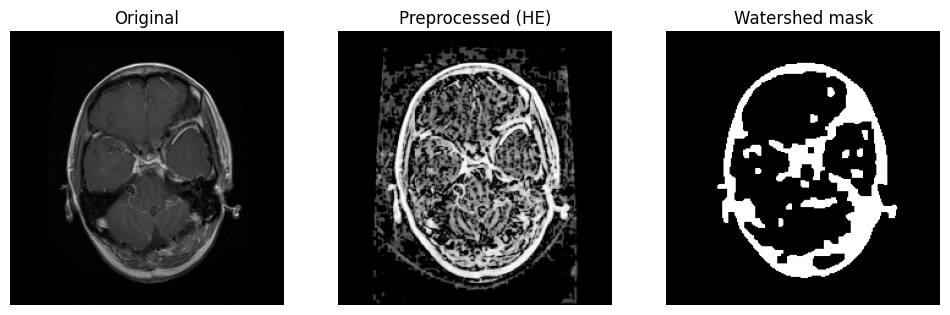

In [35]:
def show_sample(path):
    bgr = cv2.imread(path)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    pp = full_preprocess(bgr)
    ws = watershed_segment(cv2.cvtColor(pp, cv2.COLOR_RGB2GRAY))

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); plt.imshow(rgb); plt.title("Original"); plt.axis('off')
    plt.subplot(1,3,2); plt.imshow(pp, cmap='gray'); plt.title("Preprocessed (HE)"); plt.axis('off')
    plt.subplot(1,3,3); plt.imshow(ws, cmap='gray'); plt.title("Watershed mask"); plt.axis('off')
    plt.show()

# pick a random training image to inspect
some_class = sorted(os.listdir(TRAIN_DIR))[0]
some_path = glob.glob(os.path.join(TRAIN_DIR, some_class, "*"))[0]
show_sample(some_path)


In the below cell, we load our preprocessed image dataset (produced in the earlier steps) into TensorFlow using image_dataset_from_directory. This prepares the data for model training by organizing images into batches with their corresponding labels.

What this cell does:

* Training Dataset (train_ds)

  * Loaded from the PROC_TRAIN folder

  * Images are resized to IMG_SIZE × IMG_SIZE

  * Labels are inferred from directory names and encoded as one-hot vectors (label_mode='categorical')

  * Data is shuffled to ensure good mixing during training

  * A fixed seed is used to maintain reproducibility

* Validation/Test Dataset (val_test_ds)

  * Loaded from the PROC_TEST folder

  * Same preprocessing (size, labels)

  * Shuffle is disabled so results are deterministic

  * Can optionally be split further, but here we use all of it as the test set

* Finally, we extract and display class names, which are determined automatically from alphabetical folder order.

This prepares the data pipeline needed for training the CNN efficiently.

In [36]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    PROC_TRAIN,
    labels="inferred",
    label_mode="categorical",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

val_test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    PROC_TEST,
    labels="inferred",
    label_mode="categorical",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Optionally split TEST into val+test (here we’ll just use all as test for simplicity)
class_names = train_ds.class_names
class_names


Found 5712 files belonging to 4 classes.
Found 1311 files belonging to 4 classes.


['glioma', 'meningioma', 'notumor', 'pituitary']

This cell prepares the final training and testing pipelines. We define a small Keras augmentation model that performs random flips, rotations, and zooms to make the training data more diverse. Both training and test images are normalized to the
0
,
1
0,1 range, but only the training set receives augmentation. Finally, we apply TensorFlow’s prefetching to speed up data loading and improve training performance.

In [37]:
# Prefetch for speed; add simple augmentation
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
])

def aug_and_rescale(x, y):
    x = tf.cast(x, tf.float32) / 255.0
    x = data_augmentation(x, training=True)
    return x, y

def rescale_only(x, y):
    x = tf.cast(x, tf.float32) / 255.0
    return x, y

train_ds = train_ds.map(aug_and_rescale, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds  = val_test_ds.map(rescale_only, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)


The below cell defines and compiles the convolutional neural network used for brain tumor classification. The model consists of several Conv2D layers with batch normalization and pooling, followed by global average pooling and dense layers for classification. Dropout is added to reduce overfitting. The final layer uses softmax to output probabilities for all classes. After defining the architecture, we create the model and display its summary.

In [38]:
def make_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=4):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

num_classes = len(class_names)
model = make_model(num_classes=num_classes)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,748 (1.62 MB)

 Trainable params: 422,788 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

The below cell trains the CNN using the prepared training and test datasets. We use three callbacks:

ModelCheckpoint saves the best-performing model based on validation accuracy,

ReduceLROnPlateau lowers the learning rate when progress stalls, and

EarlyStopping stops training early if validation accuracy stops improving.

The model is then trained for the specified number of epochs, and the training history is recorded.

In [39]:
callbacks = [
    keras.callbacks.ModelCheckpoint("best_model.keras", monitor="val_accuracy", save_best_only=True, mode="max", verbose=1),
    keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1),
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor="val_accuracy")
]

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.6299 - loss: 0.9335
Epoch 1: val_accuracy improved from -inf to 0.29977, saving model to best_model.keras
179/179 ━━━━━━━━━━━━━━━━━━━━ 78s 363ms/step - accuracy: 0.6302 - loss: 0.9329 - val_accuracy: 0.2998 - val_loss: 4.4317 - learning_rate: 0.0010
Epoch 2/10
178/179 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.7320 - loss: 0.7191
Epoch 2: val_accuracy improved from 0.29977 to 0.31198, saving model to best_model.keras
179/179 ━━━━━━━━━━━━━━━━━━━━ 66s 327ms/step - accuracy: 0.7321 - loss: 0.7187 - val_accuracy: 0.3120 - val_loss: 5.7105 - learning_rate: 0.0010
Epoch 3/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.7863 - loss: 0.5697
Epoch 3: val_accuracy improved from 0.31198 to 0.68040, saving model to best_model.keras
179/179 ━━━━━━━━━━━━━━━━━━━━ 82s 328ms/step - accuracy: 0.7863 - loss: 0.5696 - val_accuracy: 0.6804 - val_loss: 0.9740 - learning_rate: 0.0010
Epoch 4/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 

This cell defines a helper function that plots the model’s training and validation accuracy and loss across all epochs. By calling plot_history(history), we can easily see how well the model learned over time and whether it overfit or converged properly.

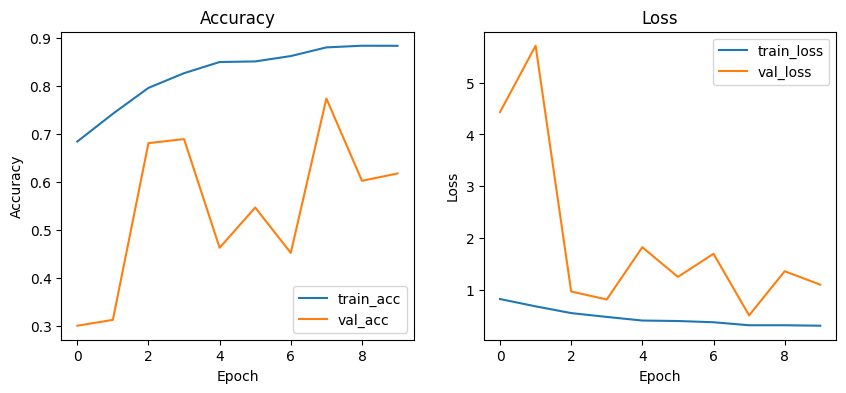

In [40]:
def plot_history(h):
    plt.figure(figsize=(10,4))
    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(h.history['accuracy'], label='train_acc')
    plt.plot(h.history['val_accuracy'], label='val_acc')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.title('Accuracy')
    # Loss
    plt.subplot(1,2,2)
    plt.plot(h.history['loss'], label='train_loss')
    plt.plot(h.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Loss')
    plt.show()

plot_history(history)


This cell evaluates the model on the test dataset by collecting the true labels and the model’s predicted probabilities. After converting these into class indices, we use classification_report to display precision, recall, F1-score, and overall performance for each tumor class. This gives a clear summary of how well the model performs on unseen data.

In [41]:
# Collect y_true and y_pred
y_true = []
y_prob = []

for batch, labels in test_ds:
    probs = model.predict(batch, verbose=0)
    y_prob.append(probs)
    y_true.append(labels.numpy())

y_prob = np.vstack(y_prob)
y_true = np.vstack(y_true)
y_pred = np.argmax(y_prob, axis=1)
y_true_idx = np.argmax(y_true, axis=1)

print(classification_report(y_true_idx, y_pred, target_names=class_names))


              precision    recall  f1-score   support

      glioma       0.97      0.52      0.68       300
  meningioma       0.59      0.59      0.59       306
     notumor       0.83      0.96      0.89       405
   pituitary       0.76      0.97      0.85       300

    accuracy                           0.77      1311
   macro avg       0.79      0.76      0.75      1311
weighted avg       0.79      0.77      0.76      1311



This cell creates a dictionary that maps each numerical class index to its corresponding class name. The mapping is then saved to a label_map.json file. This file is later used by the Gradio app to correctly interpret the model’s output and display the predicted class name.

In [42]:
# Map index->class
idx_to_class = {i:c for i,c in enumerate(class_names)}
with open("label_map.json", "w") as f:
    json.dump(idx_to_class, f)


This cell loads the trained CNN model along with the saved label map, then defines the full prediction pipeline used by the Gradio interface. When an MRI image is uploaded, it is preprocessed using the same steps as during training, passed through the model for classification, and also processed with watershed segmentation for visualization. The Gradio interface displays the predicted tumor class, confidence scores, and an annotated image showing the segmented tumor region. Finally, the app is launched so users can test the model interactively.

In [44]:
import gradio as gr

loaded = keras.models.load_model("best_model.keras")
with open("label_map.json", "r") as f:
    IDX2CLASS = json.load(f)

def preprocess_for_model(bgr):
    rgb = full_preprocess(bgr)
    x = rgb.astype(np.float32)/255.0
    x = np.expand_dims(x, axis=0)
    return x, rgb

def predict_image(img):
    """
    img arrives as a PIL Image from Gradio; convert to BGR->numpy
    """
    # Convert PIL to OpenCV BGR
    np_img = np.array(img)
    if np_img.ndim == 2:
        np_img = cv2.cvtColor(np_img, cv2.COLOR_GRAY2BGR)
    else:
        np_img = cv2.cvtColor(np_img, cv2.COLOR_RGB2BGR)

    x, pp_rgb = preprocess_for_model(np_img)
    probs = loaded.predict(x, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    pred_class = IDX2CLASS[str(pred_idx)]
    conf = float(probs[pred_idx])

    # Optional watershed mask for visualization
    ws = watershed_segment(cv2.cvtColor(pp_rgb, cv2.COLOR_RGB2GRAY))

    # Overlay mask outline on the preprocessed image
    contours, _ = cv2.findContours(ws, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    vis = pp_rgb.copy()
    cv2.drawContours(vis, contours, -1, (255,0,0), 2)  # blue outline

    # Build nice label string
    topk = sorted([(IDX2CLASS[str(i)], float(p)) for i,p in enumerate(probs)], key=lambda x: x[1], reverse=True)
    top_text = "\n".join([f"{c}: {p:.3f}" for c,p in topk])

    return pred_class, f"confidence: {conf:.3f}\n\nclass probabilities:\n{top_text}", vis

demo = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil", label="Upload brain MRI"),
    outputs=[
        gr.Textbox(label="Predicted class"),
        gr.Textbox(label="Details",lines=6, max_lines=20),
        gr.Image(label="Preprocessed + watershed outline")
    ],
    title="Brain Tumor Detection (CNN + Classical Preprocessing)",
    description="Uploads an MRI image, runs anisotropic diffusion, skull stripping, top-hat + histogram equalization, and predicts class."
)

demo.launch(debug=False, share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8b7ab40239df2f8aa6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
